In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df["price"].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [8]:
import matplotlib.pyplot as plt

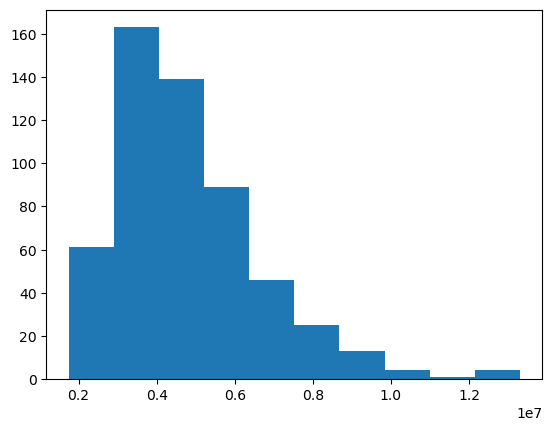

In [9]:
plt.hist(df["price"])
plt.show()

In [10]:
df.select_dtypes(include="object").columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
binary_column  = ["mainroad", "guestroom", "basement", "hotwaterheating",
       "airconditioning", "prefarea"]
binary_column

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea']

In [12]:
for col in binary_column:
    df[col] = df[col].map({"yes":1, "no":0})

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [14]:
df["furnishingstatus"].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [15]:
df = pd.get_dummies(
    df, columns = ["furnishingstatus"], drop_first = True
)

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [17]:
import seaborn as sns

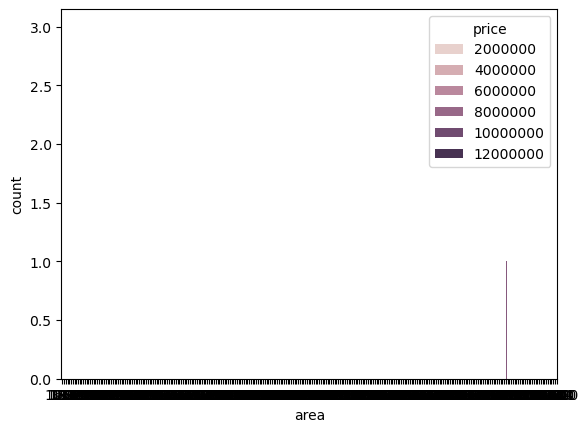

In [18]:
sns.countplot(x = "area", hue = "price", data = df)
plt.show()

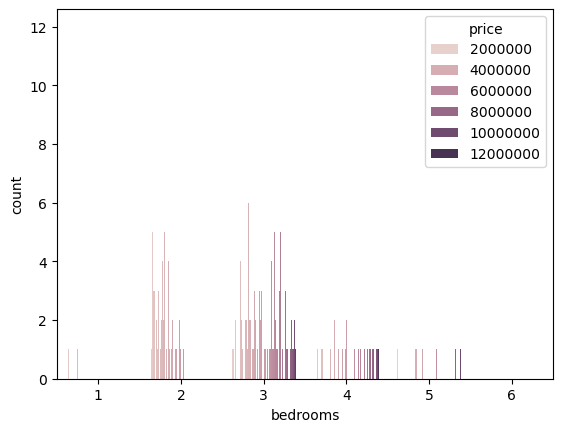

In [19]:
sns.countplot(x = "bedrooms", hue = "price", data = df)
plt.show()

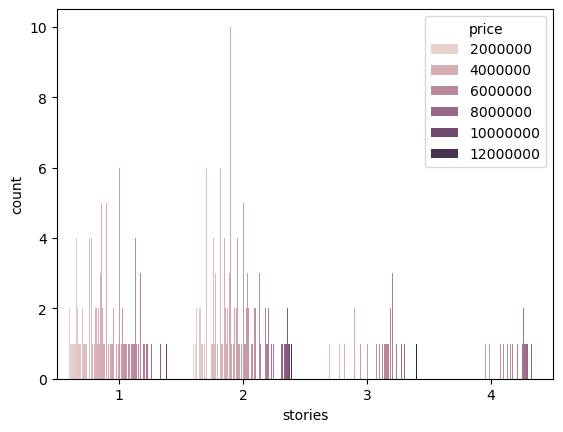

In [20]:
sns.countplot(x = "stories", hue = "price", data = df)
plt.show()

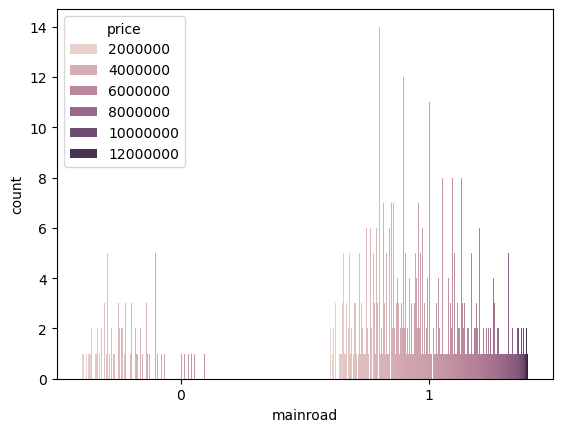

In [21]:
sns.countplot(x = "mainroad", hue = "price", data = df)
plt.show()

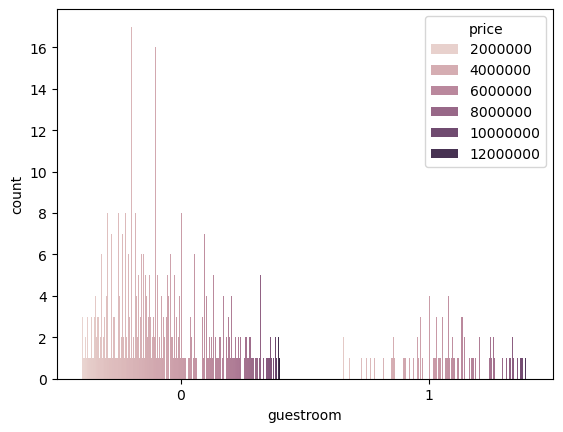

In [22]:
sns.countplot(x = "guestroom", hue = "price", data = df)
plt.show()

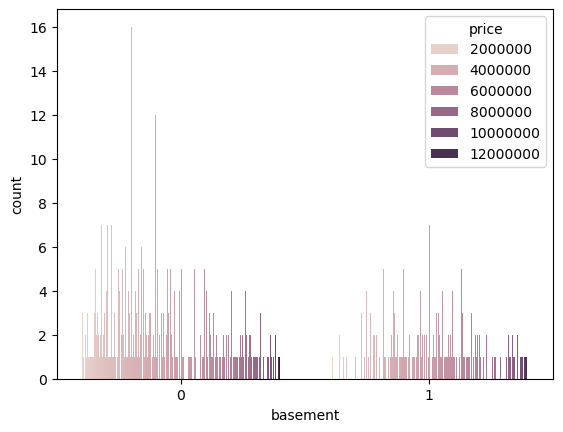

In [23]:
sns.countplot(x = "basement", hue = "price", data = df)
plt.show()

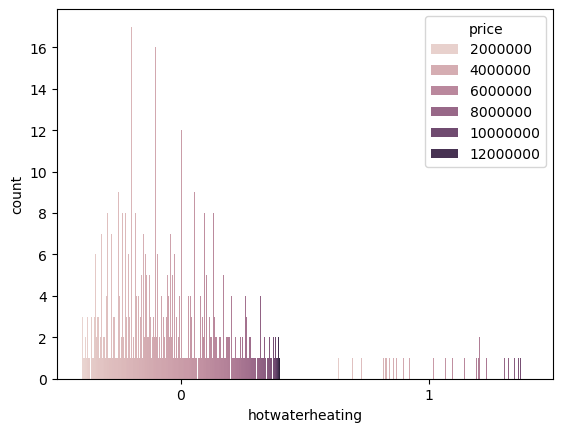

In [24]:
sns.countplot(x = "hotwaterheating", hue = "price", data = df)
plt.show()

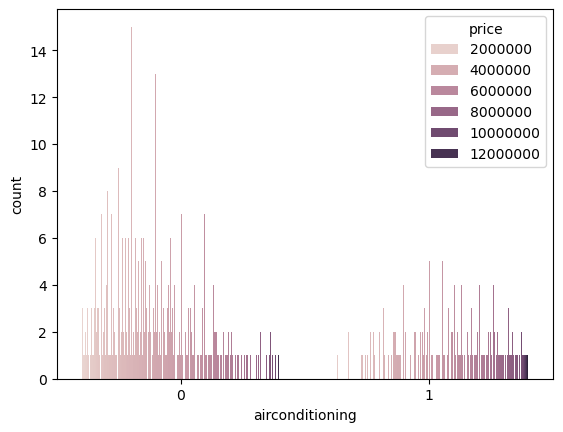

In [25]:
sns.countplot(x = "airconditioning", hue = "price", data = df)
plt.show()

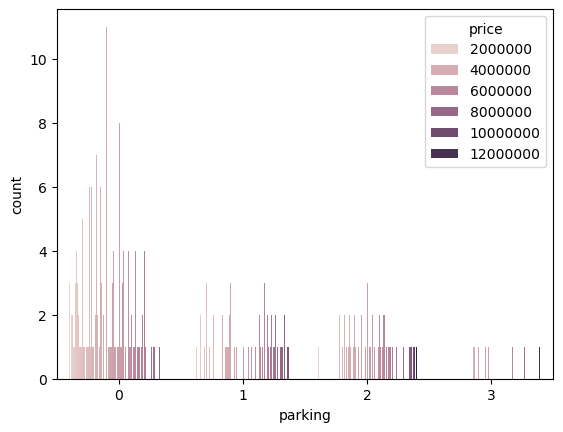

In [26]:
sns.countplot(x = "parking", hue = "price", data = df)
plt.show()

In [27]:
y = df["price"]

In [28]:
X = df.drop("price", axis = 1)

In [29]:
X.shape

(545, 13)

In [30]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
linear_model = LinearRegression()

In [35]:
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
lr_pred = linear_model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score

print(r2_score(y_test, lr_pred))

0.6529242642153187


In [57]:
from sklearn.tree import DecisionTreeRegressor

In [58]:
dt_model = DecisionTreeRegressor(  max_depth=5,
    min_samples_split=5,
    random_state=42
)

In [59]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [60]:
dtr_predict = dt_model.predict(X_test)

In [61]:
from sklearn.metrics import r2_score

score = r2_score(y_test, dtr_predict)

print(score)

0.4653641401291746


In [62]:
print("Linear Regression :", r2_score(y_test, lr_pred))
print("Decision Tree :", r2_score(y_test, dtr_predict))

Linear Regression : 0.6529242642153187
Decision Tree : 0.4653641401291746
